<a href="https://colab.research.google.com/github/jairaj023/Internship-Practice/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


In [ ]:
credit = pd.read_csv('credit_card_fraud_10k.csv')

In [ ]:
credit.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [ ]:
credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [ ]:
credit.isnull().sum()

,0
transaction_id,0
amount,0
transaction_hour,0
merchant_category,0
foreign_transaction,0
location_mismatch,0
device_trust_score,0
velocity_last_24h,0
cardholder_age,0
is_fraud,0


In [ ]:
credit[credit.duplicated()].shape

(0, 10)

In [ ]:
credit.shape

(10000, 10)

In [ ]:
credit.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [ ]:
credit["is_fraud"].value_counts()

,count
is_fraud,
0,9849
1,151


In [ ]:
credit['is_fraud'].value_counts(normalize=True) * 100

,proportion
is_fraud,
0,98.49
1,1.51


Traction Analysis

In [ ]:
#Total Transaction

print("Total Transaction: ", len(credit))
print("Total Fraud Transaction: ", credit['is_fraud'].sum())
Fraud_percentage = (credit['is_fraud'].sum() / len(credit)) * 100
print("Fraud Percentage: {:.4f}% ", format(Fraud_percentage))

Total Transaction:  10000
Total Fraud Transaction:  151
Fraud Percentage: {:.4f}%  1.51


Amount Analysis

In [ ]:
print("Maximum Transaction: ", credit['amount'].max())
print("Manimum Transaction: ", credit['amount'].min())
print("Average Transaction: ", credit['amount'].mean())
print("Median Transaction: ", credit['amount'].median())

Maximum Transaction:  1471.04
Manimum Transaction:  0.0
Average Transaction:  175.94984899999997
Median Transaction:  122.095


Time Analysis

In [ ]:
credit['transaction_hour'] = (credit['transaction_hour'] // 3600) % 24

# Fraud By Hour

fraud_by_hour = credit[credit['is_fraud']==1].groupby('transaction_hour').size()
print(fraud_by_hour)

# peak Fraud Hours

print("Peak Fraud Hours: ")
print(fraud_by_hour.sort_values(ascending=False).head())

transaction_hour
0    151
dtype: int64
Peak Fraud Hours: 
transaction_hour
0    151
dtype: int64


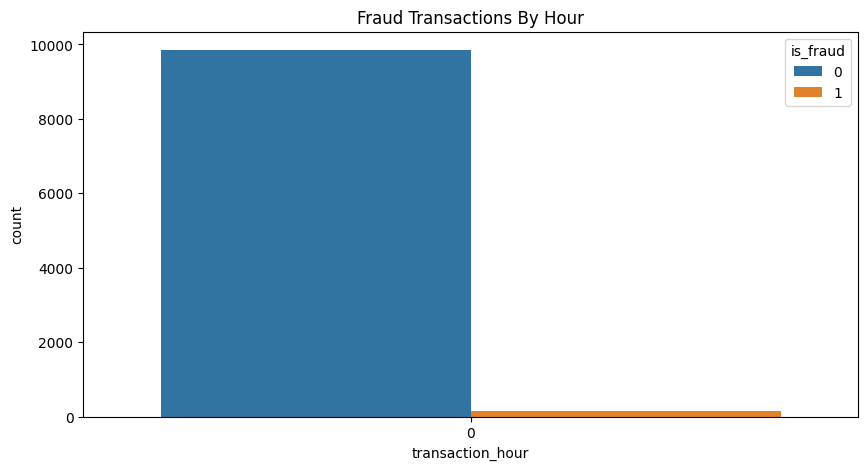

In [ ]:
# Fraud By Time Distribution

plt.figure(figsize=(10,5))
sns.countplot(x = 'transaction_hour', hue = 'is_fraud', data = credit)
plt.title("Fraud Transactions By Hour")
plt.show()

**VISUALISATION**

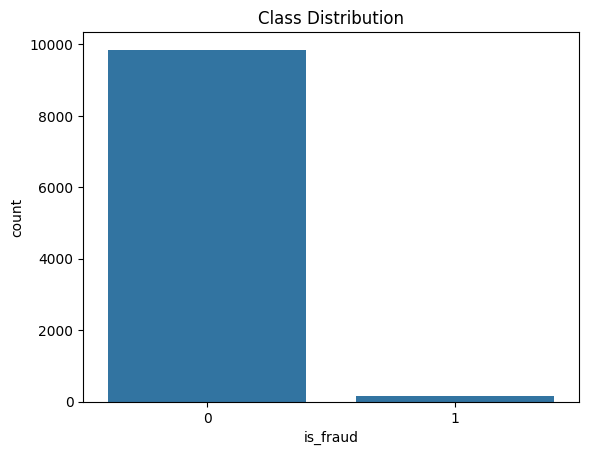

In [ ]:
# Count Plot

sns.countplot(x='is_fraud', data=credit)
plt.title('Class Distribution')
plt.show()

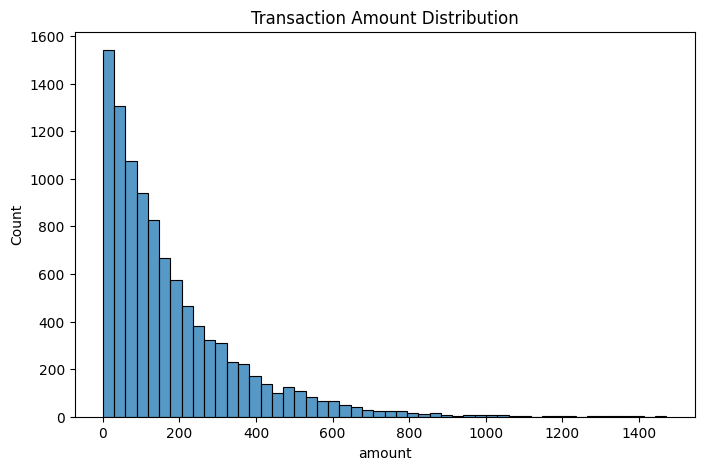

In [ ]:
# Histogram

plt.figure(figsize=(8,5))
sns.histplot(credit["amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

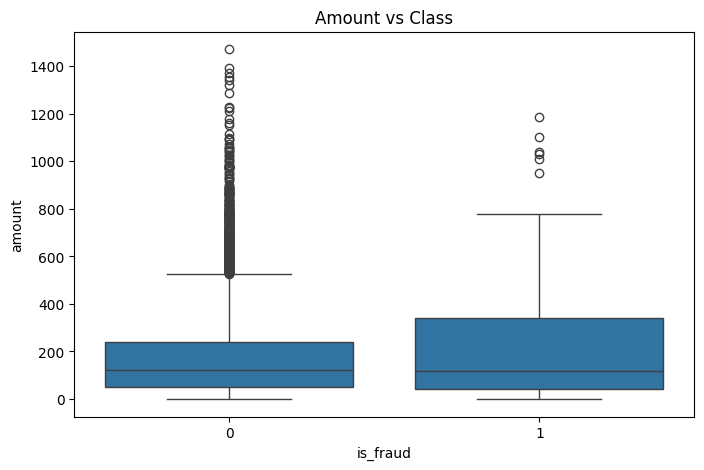

In [ ]:
# Box Plot

plt.figure(figsize=(8,5))
sns.boxplot(x="is_fraud", y="amount", data=credit)
plt.title("Amount vs Class")
plt.show()

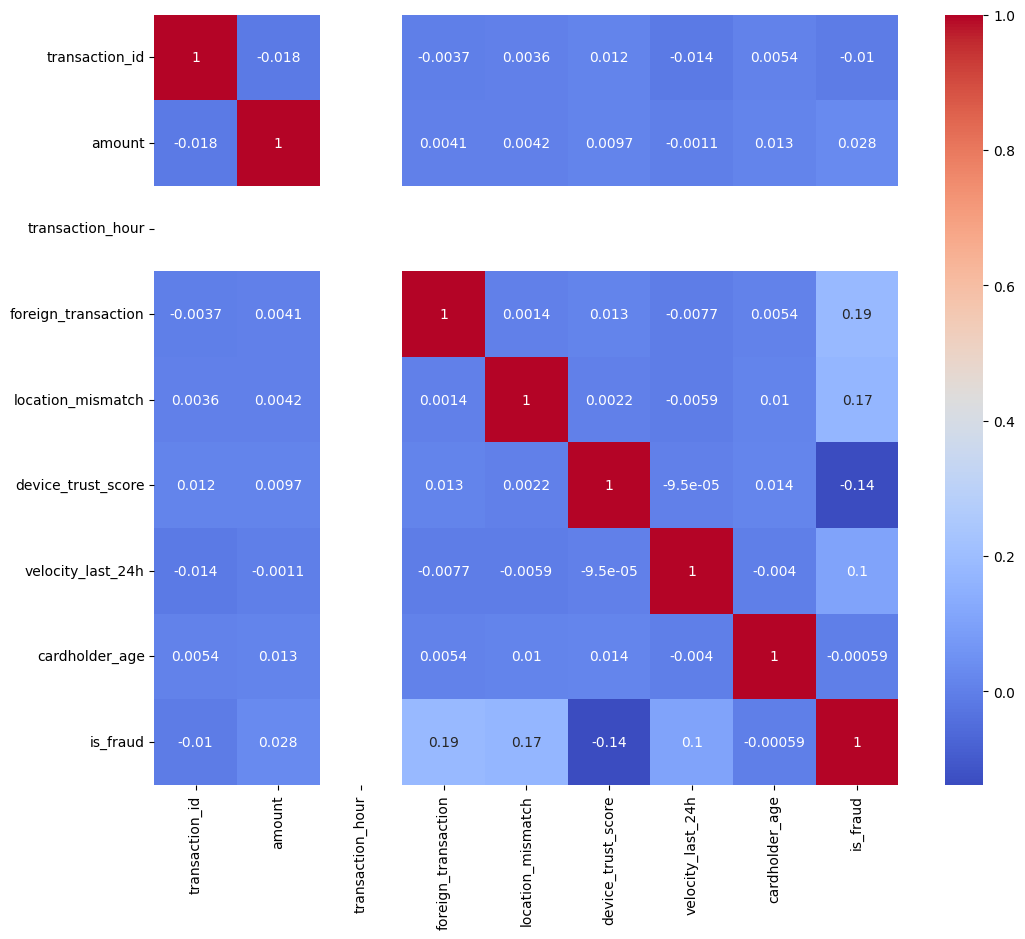

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(credit.select_dtypes(include='number').corr(),  annot=True, cmap='coolwarm')
plt.show()

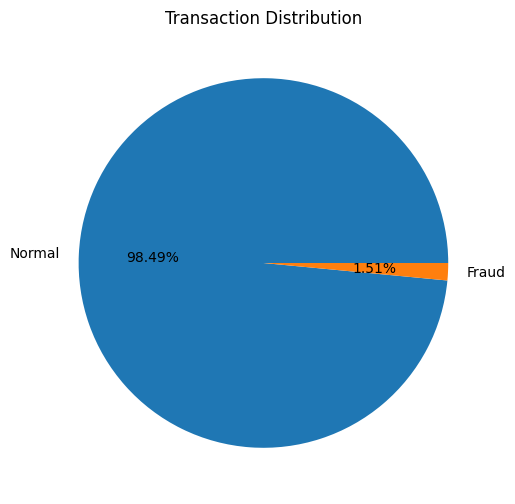

In [ ]:
# Pie Chart

credit['is_fraud'].value_counts().plot(
    kind='pie',
    autopct = '%1.2f%%',
    labels = ['Normal', 'Fraud'],
    figsize=(6,6)
)
plt.title("Transaction Distribution")
plt.ylabel(" ")
plt.show()

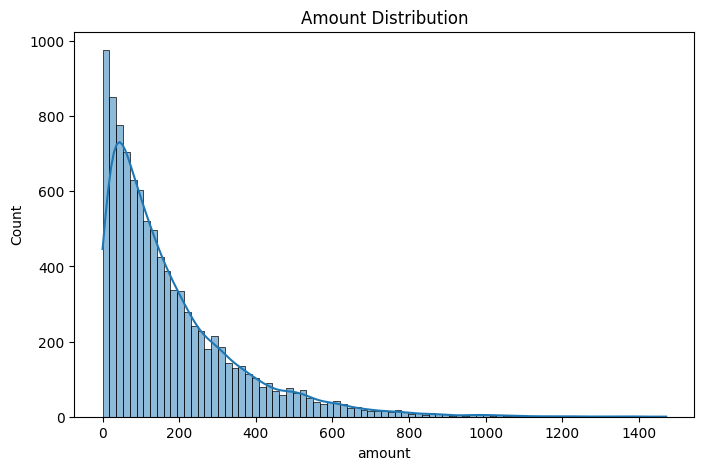

In [ ]:
# Distribution Plot

plt.figure(figsize=(8,5))
sns.histplot(credit["amount"], kde=True)
plt.title("Amount Distribution")
plt.show()

In [ ]:
x = credit.drop('is_fraud', axis=1)
y = credit['is_fraud']

In [ ]:
x.dtypes

,0
transaction_id,int64
amount,float64
transaction_hour,int64
merchant_category,object
foreign_transaction,int64
location_mismatch,int64
device_trust_score,int64
velocity_last_24h,int64
cardholder_age,int64


In [ ]:
x = pd.get_dummies(x, columns=['merchant_category'], drop_first=True)

In [ ]:
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

In [ ]:
score = np.mean(cross_val_score(LogisticRegression(max_iter=1000),x,y,scoring='accuracy',cv=20))

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [ ]:
print("Cross-validation accuracy:", score)

Cross-validation accuracy: 0.9868


In [ ]:

print("Cross-validation accuracy:", score * 100,"%")

Cross-validation accuracy: 98.68 %
